
Training RNN...


c:\Users\rohan\anaconda3\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 31s 101ms/step - accuracy: 0.7853 - loss: 0.4433 - val_accuracy: 0.8518 - val_loss: 0.3540
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 99ms/step - accuracy: 0.8929 - loss: 0.2680 - val_accuracy: 0.8378 - val_loss: 0.3730
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 25s 102ms/step - accuracy: 0.9325 - loss: 0.1847 - val_accuracy: 0.8616 - val_loss: 0.3866

Training LSTM...
Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 58s 224ms/step - accuracy: 0.8095 - loss: 0.4115 - val_accuracy: 0.8490 - val_loss: 0.3483
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 125s 501ms/step - accuracy: 0.9066 - loss: 0.2389 - val_accuracy: 0.8773 - val_loss: 0.3272
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 110s 439ms/step - accuracy: 0.9291 - loss: 0.1883 - val_accuracy: 0.8834 - val_loss: 0.2962
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 99s 397ms/step - accuracy: 0.9483 - loss: 0.1422 - val_accuracy: 0.8759 - val_loss: 0.3320
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 85s 342ms/step - accuracy: 0.952

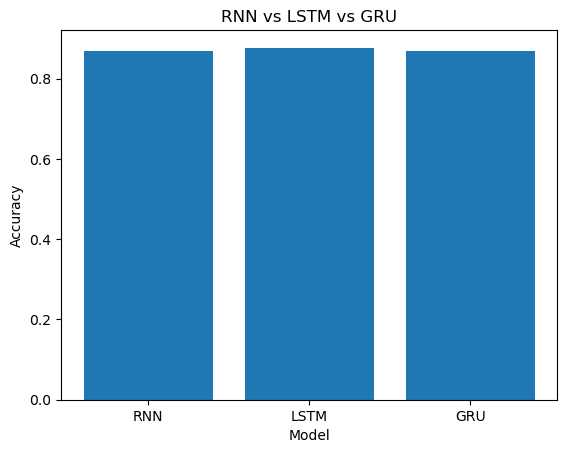

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Embedding
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv('IMDB Dataset.csv')

# Encode labels
df['sentiment'] = df['sentiment'].map({'positive':1, 'negative':0})

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    df['review'], df['sentiment'], test_size=0.2, random_state=42
)

# Tokenization
max_words = 10000
max_len = 200

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# Padding
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=2)

# 🔹 Function to build models
def build_model(model_type):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=128, input_length=max_len))

    if model_type == 'RNN':
        model.add(SimpleRNN(64))
    elif model_type == 'LSTM':
        model.add(LSTM(64))
    elif model_type == 'GRU':
        model.add(GRU(64))

    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# 🔹 Train models
models = {}
histories = {}

for model_type in ['RNN', 'LSTM', 'GRU']:
    print(f"\nTraining {model_type}...")
    model = build_model(model_type)

    history = model.fit(
        X_train_pad, y_train,
        validation_split=0.2,
        epochs=5,
        batch_size=128,
        callbacks=[early_stop],
        verbose=1
    )

    models[model_type] = model
    histories[model_type] = history

# 🔹 Evaluate models
results = {}

for model_type, model in models.items():
    loss, acc = model.evaluate(X_test_pad, y_test, verbose=0)
    results[model_type] = acc
    print(f"{model_type} Accuracy: {acc:.4f}")

# 🔹 Plot comparison
plt.figure()
plt.bar(results.keys(), results.values())
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("RNN vs LSTM vs GRU")
plt.show()